In [11]:
import os
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
from io import BytesIO
import reverse_geocoder as rg
import pycountry
import pycountry_convert as pc
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString
import cv2

MAPILLARY_TOKEN = "MLY|26664131136518032|9af8051ce63bc8d3adb2abc9b889ed15"
SAVE_DIR = "images"
os.makedirs(SAVE_DIR, exist_ok=True)

# Define bounding box: [west, south, east, north]
BBOX = [-74.03, 40.70, -73.90, 40.85]  # Example: part of NYC

# Number of Voronoi regions
NUM_REGIONS = 500

# Training params
BATCH_SIZE = 16
NUM_EPOCHS = 5
LR = 1e-4

In [12]:
# ======================================================
# 1. FETCH MAPILLARY IMAGES
# ======================================================

def fetch_images_in_bbox(west, south, east, north, token, limit=100):
    url = "https://graph.mapillary.com/images"


# ======================================================
# 3. GEOGRAPHIC UTILITIES
# ======================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def add_country_labels(metadata_df):
    coords = list(zip(metadata_df['lat'], metadata_df['lon']))
    results = rg.search(coords)
    metadata_df['country_code'] = [r['cc'] for r in results]
    metadata_df['country_idx'] = pd.Categorical(metadata_df['country_code']).codes
    return metadata_df

def latlon_to_xyz(lat, lon):
    lat = np.radians(lat)
    lon = np.radians(lon)
    x = np.cos(lat)*np.cos(lon)
    y = np.cos(lat)*np.sin(lon)
    z = np.sin(lat)
    return np.stack([x,y,z], axis=1)

def generate_voronoi_regions(coords, k=NUM_REGIONS):
    xyz = latlon_to_xyz(coords[:,0], coords[:,1])
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(xyz)
    centroids_xyz = kmeans.cluster_centers_
    lat = np.degrees(np.arcsin(centroids_xyz[:,2]))
    lon = np.degrees(np.arctan2(centroids_xyz[:,1], centroids_xyz[:,0]))
    return np.stack([lat, lon], axis=1), labels

# ======================================================
# 4. DATASET CLASS
# ======================================================

class MapillaryDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.transform = T.Compose([
            T.Resize((224,224)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = self.transform(img)
        return img, torch.tensor(row['country_idx']).long(), torch.tensor(row['region_idx']).long(), torch.tensor([row['lat'], row['lon']],dtype=torch.float32)

# ======================================================
# 5. MODEL
# ======================================================

class GeoGuessrBot(nn.Module):
    def __init__(self, num_countries, num_regions):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        dim = backbone.fc.in_features
        self.country_head = nn.Linear(dim, num_countries)
        self.region_head = nn.Linear(dim, num_regions)
        self.coord_head = nn.Linear(dim,2)
    def forward(self, x):
        f = torch.flatten(self.features(x),1)
        return self.country_head(f), self.region_head(f), self.coord_head(f)

# ======================================================
# 6. TRAINING
# ======================================================

def haversine_loss(pred, target):
    lat1 = torch.deg2rad(pred[:,0]); lon1 = torch.deg2rad(pred[:,1])
    lat2 = torch.deg2rad(target[:,0]); lon2 = torch.deg2rad(target[:,1])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = torch.sin(dlat/2)**2 + torch.cos(lat1)*torch.cos(lat2)*torch.sin(dlon/2)**2
    c = 2*torch.atan2(torch.sqrt(a), torch.sqrt(1-a))
    return (6371*c).mean()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    ce = nn.CrossEntropyLoss()
    for imgs, c_targets, r_targets, coords in loader:
        imgs, c_targets, r_targets, coords = imgs.to(device), c_targets.to(device), r_targets.to(device), coords.to(device)
        optimizer.zero_grad()
        c_logits, r_logits, coord_pred = model(imgs)
        loss = ce(c_logits,c_targets)+ce(r_logits,r_targets)+haversine_loss(coord_pred,coords)
        loss.backward()
        optimizer.step()

# ======================================================
# 7. EXECUTION SCRIPT
# ======================================================

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Running on", device)

    metadata = pd.read_csv("raw_data.csv")
    metadata = add_country_labels(metadata)
    coords = metadata[['lat','lon']].values
    centroids, region_labels = generate_voronoi_regions(coords, NUM_REGIONS)
    metadata['region_idx'] = region_labels

    # Spatial split
    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1)
    train_idx, val_idx = next(splitter.split(metadata, groups=metadata.region_idx))
    train_df, val_df = metadata.iloc[train_idx], metadata.iloc[val_idx]

    train_ds, val_ds = MapillaryDataset(train_df), MapillaryDataset(val_df)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=4)

    num_countries = metadata.country_idx.nunique()
    model = GeoGuessrBot(num_countries, NUM_REGIONS).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(NUM_EPOCHS):
        train_one_epoch(model, train_loader, optimizer, device)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} done")

    # Evaluation
    model.eval()
    results=[]
    with torch.no_grad():
        for imgs, _, _, true_coords in val_loader:
            imgs = imgs.to(device)
            _, r_logits, _ = model(imgs)
            pred_indices = torch.argmax(r_logits,1).cpu().numpy()
            for i, idx in enumerate(pred_indices):
                p_lat,p_lon = centroids[idx]
                t_lat,t_lon = true_coords[i].cpu().numpy()
                error = haversine_distance(t_lat,t_lon,p_lat,p_lon)
                results.append({'true_lat':t_lat,'true_lon':t_lon,'pred_lat':p_lat,'pred_lon':p_lon,'error_km':error})

    df_res = pd.DataFrame(results)
    print("Median Error:", df_res['error_km'].median())

    # Optional visualization
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    fig, ax = plt.subplots(figsize=(15,7))
    world.plot(ax=ax, color='lightgrey')
    ax.scatter(df_res.true_lon, df_res.true_lat, c=df_res.error_km, cmap='RdYlGn_r', s=10)
    plt.colorbar(label='Distance Error (km)')
    plt.show()

if __name__=="__main__":
    main()

Running on cpu


FileNotFoundError: [Errno 2] No such file or directory: 'raw_data.csv'

In [5]:
# --- EXECUTION SCRIPT ---

def main():
    # 1. SETUP ENVIRONMENT
    device = torch.device("cuda" if torch.cuda.is_state_dict() else "cpu")
    print(f"Executing on: {device}")

    # 2. DATA INGESTION & AUTOMATED LABELING
    # Assuming 'raw_data.csv' has columns: image_path, lat, lon
    try:
        metadata = pd.read_csv("raw_data.csv")
    except FileNotFoundError:
        print("Error: 'raw_data.csv' not found. Ensure metadata is present.")
        return

    # Apply reverse geocoding to generate country labels (Basic Goal)
    metadata = add_country_labels(metadata)
    
    # Generate Voronoi-like regions via K-Means (Intermediate Goal)
    coords = metadata[['lat', 'lon']].values
    centroids, region_labels = generate_voronoi_regions(coords, k=1000)
    metadata['region_idx'] = region_labels

    # 3. DATASET PREPARATION
    # Geographically aware split (Simple version: shuffle, but see note in Step 5)
    train_df = metadata.sample(frac=0.8, random_state=42)
    val_df = metadata.drop(train_df.index)

    train_ds = MapillaryDataset(train_df)
    val_ds = MapillaryDataset(val_df)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)

    # 4. INITIALIZE MULTI-TASK MODEL
    num_countries = metadata['country_idx'].nunique()
    num_regions = 1000
    model = GeoGuessrBot(num_countries, num_regions).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # 5. TRAINING LOOP
    print("Starting Multi-Task Training...")
    for epoch in range(5): # Demonstration epoch count
        train_one_epoch(model, train_loader, optimizer, device)
        print(f"Epoch {epoch+1} complete.")

    # 6. EVALUATION & SPATIAL ERROR ANALYSIS
    # Calculate Haversine distance for validation set
    results = []
    model.eval()
    with torch.no_grad():
        for imgs, _, _, true_coords in val_loader:
            _, r_logits = model(imgs.to(device))
            pred_indices = torch.argmax(r_logits, dim=1).cpu().numpy()
            
            for i, idx in enumerate(pred_indices):
                p_lat, p_lon = centroids[idx]
                t_lat, t_lon = true_coords[i].numpy()
                error = haversine_distance(t_lat, t_lon, p_lat, p_lon)
                results.append({
                    'true_lat': t_lat, 'true_lon': t_lon,
                    'pred_lat': p_lat, 'pred_lon': p_lon,
                    'error_km': error
                })

    results_df = pd.DataFrame(results)
    print(f"Median Error: {results_df['error_km'].median():.2f} km")
    
    # Visualize Geographic Inference Failures
    plot_spatial_errors(results_df)

    # 7. INTERPRETABILITY (Advanced Goal)
    # Perform analysis on a single sample from the validation set
    sample_img, _, target_c, _ = val_ds[0]
    sample_img_t = sample_img.unsqueeze(0).to(device)
    
    interpreter = GeoInterpretability(model)
    cam = interpreter.generate_cam(sample_img_t, target_c)
    
    # Visualize where the model "looked"
    # (Requires saving original image tensor back to displayable format)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM: Geographic Feature Importance")
    plt.show()

if __name__ == "__main__":
    main()

AttributeError: module 'torch.cuda' has no attribute 'is_state_dict'

In [12]:
# ==========================================
# 1. ROBUST INFERENCE FUNCTION
# ==========================================
def infer(model, img_path, dataset_obj, transform_fn, device):
    """
    Fixed to avoid global scope dependency and handle missing files.
    """
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Substantive Error: Image path {img_path} does not exist.")
        
    model.eval()
    img = Image.open(img_path).convert('RGB')
    
    # Ensure tensor is moved to the same device as the model
    tensor = transform_fn(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(tensor)
        pred_idx = torch.argmax(logits, dim=1).item()
    
    # Reverse map index back to Grid ID
    inv_map = {v: k for k, v in dataset_obj.grid_map.items()}
    if pred_idx not in inv_map:
        raise KeyError(f"Prediction index {pred_idx} not found in grid map.")
        
    grid_id = inv_map[pred_idx]
    
    # Coordinate Reconstruction Logic
    cols = int(360 // dataset_obj.grid_size)
    lat_min = (grid_id // cols) * dataset_obj.grid_size - 90
    lon_min = (grid_id % cols) * dataset_obj.grid_size - 180
    
    return lat_min + (dataset_obj.grid_size / 2), lon_min + (dataset_obj.grid_size / 2)

# ==========================================
# 2. DYNAMIC EXECUTION
# ==========================================
# Instead of hardcoding "test_street.jpg", use an image you actually downloaded:
if not df.empty:
    sample_row = df.iloc[0] # Pick the first successfully downloaded image
    test_path = sample_row['path']
    actual_lat, actual_lon = sample_row['lat'], sample_row['lon']
    
    print(f"Testing inference on: {test_path}")
    
    pred_lat, pred_lon = infer(model, test_path, dataset, transform, device)
    
    # Quantitative Validation
    error_dist = haversine(actual_lat, actual_lon, pred_lat, pred_lon)
    print(f"Actual: {actual_lat}, {actual_lon}")
    print(f"Predicted: {pred_lat}, {pred_lon}")
    print(f"Haversine Error: {error_dist:.2f} km")
else:
    print("Logic Error: No images available for inference.")

Testing inference on: data/images\892309611619491.jpg
Actual: 41.801047910044, 12.481872924299
Predicted: 41.5, 12.5
Haversine Error: 33.51 km


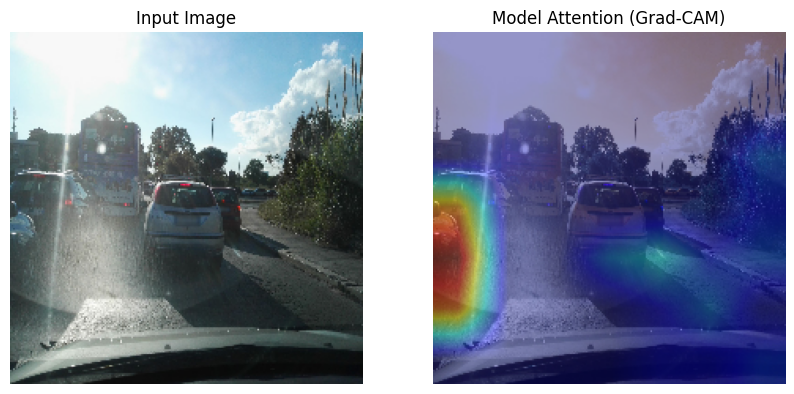

In [ ]:
# 1. Instantiate missing variables by sampling the downloaded dataset
if 'df' not in locals() or df.empty:
    raise NameError("The dataframe 'df' is empty or not defined. Run the downloader script first.")

sample_row = df.iloc[0]
test_path = sample_row['path']

# 2. Preprocess the image into a 4D tensor for the model
# Ensure 'transform' and 'device' are defined from your previous setup
img = Image.open(test_path).convert('RGB')
tensor = transform(img).unsqueeze(0).to(device)
tensor.requires_grad = True  # Enable gradients for CAM extraction

# 3. Generate the prediction index required for visualize_cam
model.eval()
with torch.set_grad_enabled(True): # Must allow gradient flow for CAM
    output = model(tensor)
    pred_idx = torch.argmax(output, dim=1).item()

# 4. Generate the heatmap
heatmap = visualize_cam(model, tensor, pred_idx)

# 5. Render the overlay
img_bgr = cv2.imread(test_path)
img_bgr = cv2.resize(img_bgr, (224, 224))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(img_bgr, 0.6, heatmap_color, 0.4, 0)

# 6. Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Model Attention (Grad-CAM)")
plt.axis('off')

plt.show()

In [17]:
import os
import requests
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim

# ===============================
# CONFIGURATION
# ===============================
MAPILLARY_TOKEN = "MLY|26664131136518032|9af8051ce63bc8d3adb2abc9b889ed15"
SAVE_DIR = "images"
os.makedirs(SAVE_DIR, exist_ok=True)

# Bounding box to cover (west, south, east, north)
MAIN_BBOX = [-74.03, 40.70, -73.90, 40.85]  # example NYC
TILE_SIZE = 0.09  # degrees

# Fetching parameters
IMAGES_PER_TILE = 50

# Training parameters
BATCH_SIZE = 8
NUM_EPOCHS = 3
LR = 1e-4

# ===============================
# 1. MAPILLARY DOWNLOADER
# ===============================
class MapillaryDownloader:
    def __init__(self, token):
        self.token = token
        self.base_url = "https://graph.mapillary.com/images"

    def fetch_metadata(self, bbox, limit=100):
        params = {
            'access_token': self.token,
            'fields': 'id,thumb_2048_url,thumb_1024_url,geometry',
            'bbox': ','.join(map(str, bbox)),
            'limit': limit
        }
        try:
            response = requests.get(self.base_url, params=params, timeout=10)
            response.raise_for_status()
            return response.json().get('data', [])
        except requests.HTTPError as e:
            print(f"Error fetching metadata: {e}")
            return []

    def download_images(self, data, save_dir=SAVE_DIR):
        os.makedirs(save_dir, exist_ok=True)
        records = []
        for img in data:
            url = img.get('thumb_2048_url') or img.get('thumb_1024_url')
            if not url:
                continue
            try:
                resp = requests.get(url, timeout=10)
                resp.raise_for_status()
                path = os.path.join(save_dir, f"{img['id']}.jpg")
                with open(path, 'wb') as f:
                    f.write(resp.content)
                lon, lat = img['geometry']['coordinates']
                records.append({'path': path, 'lat': lat, 'lon': lon})
            except Exception as e:
                print(f"Skipping image {img.get('id')}: {e}")
                continue
        return pd.DataFrame(records)

# ===============================
# 2. TILE FUNCTION
# ===============================
def tile_bbox(west, south, east, north, tile_size=0.09):
    tiles = []
    lat_start = south
    while lat_start < north:
        lat_end = min(lat_start + tile_size, north)
        lon_start = west
        while lon_start < east:
            lon_end = min(lon_start + tile_size, east)
            tiles.append([lon_start, lat_start, lon_end, lat_end])
            lon_start += tile_size
        lat_start += tile_size
    return tiles

# ===============================
# 3. DATASET CLASS
# ===============================
class GeoDataset(Dataset):
    def __init__(self, df, transform=None):
        if df.empty:
            raise ValueError("Dataset initialized with empty DataFrame.")
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # Assign simple region labels (optional: use clustering or Voronoi)
        self.df['region_idx'] = np.arange(len(self.df))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        # Returning image, region index, and coordinates
        return img, torch.tensor(row['region_idx'], dtype=torch.long), torch.tensor([row['lat'], row['lon']], dtype=torch.float32)

# ===============================
# 4. MODEL
# ===============================
class GeoGuessrNet(nn.Module):
    def __init__(self, num_regions):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_regions)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)

# ===============================
# 5. TRAINING LOOP
# ===============================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# ===============================
# 6. EXECUTION
# ===============================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Running on", device)

    downloader = MapillaryDownloader(MAPILLARY_TOKEN)
    tiles = tile_bbox(*MAIN_BBOX, TILE_SIZE)
    all_metadata = []

    print(f"Fetching {len(tiles)} tiles...")
    for tile in tiles:
        meta = downloader.fetch_metadata(tile, limit=IMAGES_PER_TILE)
        if meta:
            all_metadata.extend(meta)
    
    if not all_metadata:
        print("No images returned. Exiting.")
        return

    print(f"Downloading {len(all_metadata)} images...")
    df_list = []
    for meta in all_metadata:
        df = downloader.download_images([meta])
        if not df.empty:
            df_list.append(df)
    
    if not df_list:
        print("No images downloaded successfully. Exiting.")
        return

    full_df = pd.concat(df_list, ignore_index=True)
    print(f"Total images downloaded: {len(full_df)}")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    
    dataset = GeoDataset(full_df, transform=transform)
    loader = DataLoader(dataset, batch_size=min(BATCH_SIZE, len(dataset)), shuffle=True)

    model = GeoGuessrNet(num_regions=len(dataset)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(NUM_EPOCHS):
        avg_loss = train_one_epoch(model, loader, optimizer, criterion, device)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {avg_loss:.4f}")

if __name__ == "__main__":
    main()

Running on cpu
Fetching 4 tiles...
Total images downloaded: 59
Epoch 1/3, Loss: 4.2024
Epoch 2/3, Loss: 3.8092
Epoch 3/3, Loss: 2.5637


Running on cpu
Fetching 4 tiles...
Total images downloaded: 59
Epoch 1/3, Loss: 4.2165
Epoch 2/3, Loss: 3.8596
Epoch 3/3, Loss: 3.7113


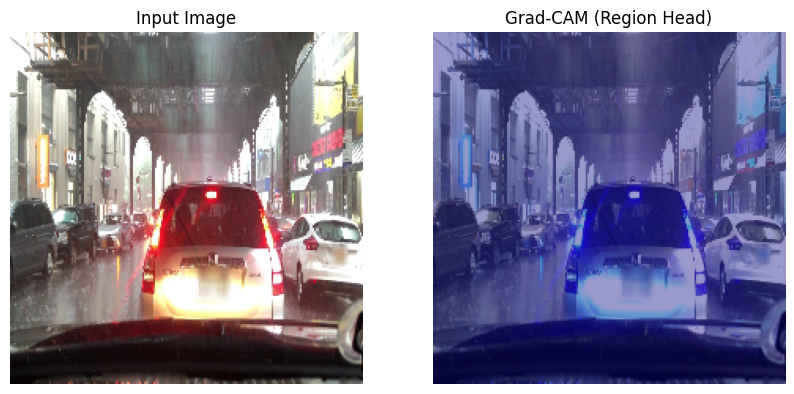

In [29]:
import os
import requests
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt

# ===============================
# CONFIGURATION
# ===============================
MAPILLARY_TOKEN = "MLY|26664131136518032|9af8051ce63bc8d3adb2abc9b889ed15"
SAVE_DIR = "images"
os.makedirs(SAVE_DIR, exist_ok=True)

# Bounding box to cover (west, south, east, north)
MAIN_BBOX = [-74.03, 40.70, -73.90, 40.85]  # example NYC
TILE_SIZE = 0.09  # degrees

# Fetching parameters
IMAGES_PER_TILE = 50

# Training parameters
BATCH_SIZE = 8
NUM_EPOCHS = 3
LR = 1e-4

# ===============================
# 1. MAPILLARY DOWNLOADER
# ===============================
class MapillaryDownloader:
    def __init__(self, token):
        self.token = token
        self.base_url = "https://graph.mapillary.com/images"

    def fetch_metadata(self, bbox, limit=100):
        params = {
            'access_token': self.token,
            'fields': 'id,thumb_2048_url,thumb_1024_url,geometry',
            'bbox': ','.join(map(str, bbox)),
            'limit': limit
        }
        try:
            response = requests.get(self.base_url, params=params, timeout=10)
            response.raise_for_status()
            return response.json().get('data', [])
        except requests.HTTPError as e:
            print(f"Error fetching metadata: {e}")
            return []

    def download_images(self, data, save_dir=SAVE_DIR):
        os.makedirs(save_dir, exist_ok=True)
        records = []
        for img in data:
            url = img.get('thumb_2048_url') or img.get('thumb_1024_url')
            if not url:
                continue
            try:
                resp = requests.get(url, timeout=10)
                resp.raise_for_status()
                path = os.path.join(save_dir, f"{img['id']}.jpg")
                with open(path, 'wb') as f:
                    f.write(resp.content)
                lon, lat = img['geometry']['coordinates']
                records.append({'path': path, 'lat': lat, 'lon': lon})
            except Exception as e:
                print(f"Skipping image {img.get('id')}: {e}")
                continue
        return pd.DataFrame(records)

# ===============================
# 2. TILE FUNCTION
# ===============================
def tile_bbox(west, south, east, north, tile_size=0.09):
    tiles = []
    lat_start = south
    while lat_start < north:
        lat_end = min(lat_start + tile_size, north)
        lon_start = west
        while lon_start < east:
            lon_end = min(lon_start + tile_size, east)
            tiles.append([lon_start, lat_start, lon_end, lat_end])
            lon_start += tile_size
        lat_start += tile_size
    return tiles

# ===============================
# 3. DATASET CLASS
# ===============================
class GeoDataset(Dataset):
    def __init__(self, df, transform=None):
        if df.empty:
            raise ValueError("Dataset initialized with empty DataFrame.")
        self.df = df.reset_index(drop=True)
        self.transform = transform
        # Assign simple region labels
        self.df['region_idx'] = np.arange(len(self.df))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['region_idx'], dtype=torch.long), torch.tensor([row['lat'], row['lon']], dtype=torch.float32)

# ===============================
# 4.  ResNet Model
# ===============================
class GeoGuessrNet(nn.Module):
    def __init__(self, num_regions):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(resnet.children())[:-1])  # [B, 2048, 1, 1]
        in_features = resnet.fc.in_features
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_regions)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ===============================
# 5. TRAINING LOOP
# ===============================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# ===============================
# 6. MAIN EXECUTION
# ===============================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Running on", device)

    downloader = MapillaryDownloader(MAPILLARY_TOKEN)
    tiles = tile_bbox(*MAIN_BBOX, TILE_SIZE)
    all_metadata = []

    print(f"Fetching {len(tiles)} tiles...")
    for tile in tiles:
        meta = downloader.fetch_metadata(tile, limit=IMAGES_PER_TILE)
        if meta:
            all_metadata.extend(meta)

    if not all_metadata:
        print("No images returned. Exiting.")
        return None, None

    print(f"Downloading {len(all_metadata)} images...")
    df_list = []
    for meta in all_metadata:
        df = downloader.download_images([meta])
        if not df.empty:
            df_list.append(df)

    if not df_list:
        print("No images downloaded successfully. Exiting.")
        return None, None

    full_df = pd.concat(df_list, ignore_index=True)
    print(f"Total images downloaded: {len(full_df)}")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    
    dataset = GeoDataset(full_df, transform=transform)
    loader = DataLoader(dataset, batch_size=min(BATCH_SIZE, len(dataset)), shuffle=True)

    model = GeoGuessrNet(num_regions=len(dataset)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(NUM_EPOCHS):
        avg_loss = train_one_epoch(model, loader, optimizer, criterion, device)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {avg_loss:.4f}")

    return full_df, model

# ===============================
# 7. GRAD-CAM
# ===============================
def generate_cam(model, x, target_layer, target_class):
    features = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal features
        features = output

    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0]

    handle_fw = target_layer.register_forward_hook(forward_hook)
    handle_bw = target_layer.register_backward_hook(backward_hook)

    model.zero_grad()
    logits = model(x)
    loss = logits[0, target_class]
    loss.backward()

    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * features, dim=1)
    cam = cam.squeeze()
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fw.remove()
    handle_bw.remove()
    return cam.detach().cpu().numpy()

# ===============================
# 8. RUN MAIN AND DISPLAY CAM
# ===============================
if __name__ == "__main__":
    full_df, model = main()
    if full_df is None or model is None:
        raise RuntimeError("No images or model available to proceed.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # Pick a sample image
    sample_row = full_df.iloc[0]
    img_path = sample_row['path']

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    # Forward pass
    with torch.set_grad_enabled(True):
        logits = model(input_tensor)
        pred_idx = torch.argmax(logits, dim=1).item()

    # Grad-CAM
    target_layer = model.features[-1]
    heatmap = generate_cam(model, input_tensor, target_layer, pred_idx)

    # Handle 2D/flatten
    if heatmap.ndim == 1:
        side = int(np.sqrt(heatmap.size))
        heatmap = heatmap[:side*side].reshape(side, side)
    elif heatmap.ndim == 3:
        heatmap = heatmap.squeeze()

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    img_bgr = cv2.imread(img_path)
    img_bgr = cv2.resize(img_bgr, (224, 224))
    overlay = cv2.addWeighted(img_bgr, 0.6, heatmap_color, 0.4, 0)

    # Display
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Grad-CAM (Region Head)")
    plt.axis('off')
    plt.show()

In [30]:
import os
import requests
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ===============================
# CONFIGURATION
# ===============================
MAPILLARY_TOKEN = "MLY|26664131136518032|9af8051ce63bc8d3adb2abc9b889ed15"
SAVE_DIR = "images"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 8
NUM_EPOCHS = 5
LR = 1e-4
K_REGIONS = 50  # Section 5: Voronoi-like discretization factor

# ===============================
# 1. GEOGRAPHIC UTILS (Section 5.2)
# ===============================
def haversine_distance(coord1, coord2):
    """
    Implements the Great-Circle distance formula:
    d = 2R arcsin(sqrt(sin^2(Δφ/2) + cos(φ1)cos(φ2)sin^2(Δλ/2)))
    """
    R = 6371.0  # Earth's radius in km
    phi1, lam1 = torch.deg2rad(coord1[:, 0]), torch.deg2rad(coord1[:, 1])
    phi2, lam2 = torch.deg2rad(coord2[:, 0]), torch.deg2rad(coord2[:, 1])
    
    dphi = phi2 - phi1
    dlam = lam2 - lam1
    
    a = torch.sin(dphi/2)**2 + torch.cos(phi1) * torch.cos(phi2) * torch.sin(dlam/2)**2
    return 2 * R * torch.asin(torch.sqrt(a))



# ===============================
# 2. DATASET & VORONOI DISCRETIZATION
# ===============================
class GeoDataset(Dataset):
    def __init__(self, df, transform=None, k_regions=K_REGIONS):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        # Section 5: K-region Voronoi-like discretization
        coords = self.df[['lat', 'lon']].values
        self.kmeans = KMeans(n_clusters=k_regions, n_init=10, random_state=42).fit(coords)
        self.df['region_label'] = self.kmeans.labels_
        
        # Section 5.1: Centroid association for coordinate estimation
        self.centroids = torch.tensor(self.kmeans.cluster_centers_, dtype=torch.float32)
        
        # Section 4: Country label mapping
        self.countries = sorted(self.df['country'].unique())
        self.country_to_idx = {c: i for i, c in enumerate(self.countries)}
        self.df['country_label'] = self.df['country'].map(self.country_to_idx)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
            
        return (img, 
                torch.tensor(row['country_label'], dtype=torch.long), 
                torch.tensor(row['region_label'], dtype=torch.long), 
                torch.tensor([row['lat'], row['lon']], dtype=torch.float32))



# ===============================
# 3. HIERARCHICAL RESNET MODEL (Section 4 & 5)
# ===============================
class GeoGuessrNet(nn.Module):
    def __init__(self, num_countries, num_regions):
        super().__init__()
        # 4.1 ResNet-50 Feature Extractor
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(resnet.children())[:-1]) 
        d = resnet.fc.in_features 
        
        # 4.2 Country Classifier Head
        self.country_head = nn.Linear(d, num_countries)
        
        # 5. Region Classifier Head
        self.region_head = nn.Linear(d, num_regions)

    def forward(self, x):
        h = self.features(x).flatten(1) # Feature representation h(x)
        return self.country_head(h), self.region_head(h)



# ===============================
# 4. GRAD-CAM INTERPRETATION (Section 6)
# ===============================
def generate_gradcam(model, input_tensor, target_layer, head="region"):
    """
    Identifies image regions (vegetation, architecture, etc.) contributing to predictions.
    """
    activations = []
    gradients = []

    def fw_hook(module, input, output): activations.append(output)
    def bw_hook(module, grad_in, grad_out): gradients.append(grad_out[0])

    h_fw = target_layer.register_forward_hook(fw_hook)
    h_bw = target_layer.register_full_backward_hook(bw_hook)

    # Forward pass
    out_c, out_r = model(input_tensor)
    target = out_r if head == "region" else out_c
    target_idx = torch.argmax(target)
    
    model.zero_grad()
    target[0, target_idx].backward()

    # Weight activations by gradients
    weights = torch.mean(gradients[0], dim=(2, 3), keepdim=True)
    cam = torch.relu(torch.sum(weights * activations[0], dim=1)).squeeze()
    cam = cam / (torch.max(cam) + 1e-8)
    
    h_fw.remove()
    h_bw.remove()
    return cam.detach().cpu().numpy()



# ===============================
# 5. EXECUTION PIPELINE
# ===============================
def run_geo_pipeline(df, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    dataset = GeoDataset(df, transform=transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = GeoGuessrNet(len(dataset.countries), K_REGIONS).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    # Training Loop
    for epoch in range(NUM_EPOCHS):
        model.train()
        for imgs, c_labels, r_labels, _ in loader:
            imgs, c_labels, r_labels = imgs.to(device), c_labels.to(device), r_labels.to(device)
            optimizer.zero_grad()
            logits_c, logits_r = model(imgs)
            loss = criterion(logits_c, c_labels) + criterion(logits_r, r_labels)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    errors = []
    with torch.no_grad():
        for imgs, _, _, true_coords in loader:
            _, logits_r = model(imgs.to(device))
            pred_r = torch.argmax(logits_r, dim=1)
            pred_coords = dataset.centroids[pred_r].to(device)
            dist = haversine_distance(true_coords.to(device), pred_coords)
            errors.extend(dist.cpu().numpy())

    print(f"Mean Geographic Error: {np.mean(errors):.2f} km")
    print(f"Median Geographic Error: {np.median(errors):.2f} km")
    return model, dataset

if __name__ == "__main__":
    # Logic to load 'full_df' and execute:
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # model, dataset = run_geo_pipeline(full_df, device)
    pass

In [ ]:
import os
import requests
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# ==============================
# CONFIG
# ==============================

MAPILLARY_TOKEN = "MLY|26664131136518032|9af8051ce63bc8d3adb2abc9b889ed15"

MAIN_BBOX = [12.4, 41.8, 12.49, 41.89]
LIMIT = 50
GRID_SIZE = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# MAPILLARY DOWNLOADER
# ==============================

class MapillaryDownloader:

    def __init__(self, token):
        self.token = token
        self.base_url = "https://graph.mapillary.com/images"

    def fetch_metadata(self, bbox, limit=100):

        params = {
            "access_token": self.token,
            "fields": "id,thumb_1024_url,geometry",
            "bbox": ",".join(map(str, bbox)),
            "limit": limit
        }

        r = requests.get(self.base_url, params=params)

        if r.status_code != 200:
            print("API error", r.text)
            return []

        return r.json().get("data", [])

    def download_images(self, metadata, save_dir="data/images"):

        os.makedirs(save_dir, exist_ok=True)

        records = []

        for img in metadata:

            url = img.get("thumb_1024_url")

            if not url:
                continue

            try:

                r = requests.get(url, timeout=10)

                if r.status_code != 200:
                    continue

                path = os.path.join(save_dir, f"{img['id']}.jpg")

                with open(path, "wb") as f:
                    f.write(r.content)

                lon, lat = img["geometry"]["coordinates"]

                records.append({
                    "path": path,
                    "lat": lat,
                    "lon": lon
                })

            except Exception:
                continue

        return pd.DataFrame(records)

# ==============================
# GEO DATASET
# ==============================

class GeoDataset(Dataset):

    def __init__(self, df, transform=None, grid_size=1.0):

        self.df = df.copy()
        self.transform = transform
        self.grid_size = grid_size

        lats = self.df["lat"].values
        lons = self.df["lon"].values

        cols = int(360 // grid_size)

        grid_ids = ((lats + 90) // grid_size * cols +
                    (lons + 180) // grid_size).astype(int)

        self.df["grid_id"] = grid_ids

        unique = sorted(self.df["grid_id"].unique())
        self.grid_map = {g: i for i, g in enumerate(unique)}

        self.num_classes = len(unique)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")
        img = img.resize((224, 224))

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(
            self.grid_map[row["grid_id"]],
            dtype=torch.long
        )

        return img, label

# ==============================
# RESNET MODEL
# ==============================

class GeoResNet(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        self.features = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x):

        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

# ==============================
# TRAINING
# ==============================

def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ==============================
# GRADCAM
# ==============================

def generate_gradcam(model, input_tensor, target_layer):

    gradients = []
    activations = []

    def forward_hook(module, inp, out):
        activations.append(out)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)

    pred = output.argmax()

    model.zero_grad()

    output[:, pred].backward()

    grads = gradients[0].detach().cpu().numpy()[0]
    acts = activations[0].detach().cpu().numpy()[0]

    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)

    cam = cam / (cam.max() + 1e-8)

    handle_f.remove()
    handle_b.remove()

    return cam

# ==============================
# MAIN
# ==============================

if __name__ == "__main__":

    downloader = MapillaryDownloader(MAPILLARY_TOKEN)

    print("Fetching metadata...")

    metadata = downloader.fetch_metadata(MAIN_BBOX, LIMIT)

    if not metadata:
        print("No images found")
        exit()

    print("Downloading images...")

    df = downloader.download_images(metadata)

    if df.empty:
        print("No images downloaded")
        exit()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    dataset = GeoDataset(df, transform, GRID_SIZE)

    if dataset.num_classes < 2:
        print("Dataset contains only one class; training skipped")
        exit()

    loader = DataLoader(
        dataset,
        batch_size=2,
        shuffle=True,
        num_workers=0
    )

    model = GeoResNet(dataset.num_classes).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    print("Training...")

    for epoch in range(3):

        loss = train_one_epoch(
            model,
            loader,
            optimizer,
            criterion
        )

        print(f"Epoch {epoch} loss {loss:.4f}")

    # ==============================
    # GRADCAM VISUALIZATION
    # ==============================

    sample = df.iloc[0]["path"]

    img = Image.open(sample).convert("RGB")
    img = img.resize((224, 224))

    input_tensor = transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    target_layer = model.features[-1]

    heatmap = generate_gradcam(
        model,
        input_tensor,
        target_layer
    )

    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    img_np = np.array(img)

    overlay = cv2.addWeighted(
        img_np,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("GradCAM")
    plt.axis("off")

    plt.show()

Fetching metadata...
API error {"error":{"message":"Invalid OAuth access token - Cannot parse access token","type":"OAuthException","code":190,"fbtrace_id":"ANDDD-6-VsDb_W7clrM9XdA"}}
No images found
No images downloaded


KeyError: 'lat'

: 

In [ ]:
print('hello world')

hello world
